# Part B: Flatness Analysis

This notebook loads the Part A checkpoints and compares SGD vs SAM using a more stable gradient-based sharpness analysis over multiple fixed ID batches.

Main question: does the SAM solution lie in a flatter local region of the loss landscape than the SGD solution?


## Part B Plan

We reuse the trained checkpoints from Part A instead of retraining from scratch. This is appropriate here because Part B is an analysis task built on top of the final SGD and SAM models.

We use two complementary views:

1. **Batch-averaged gradient sharpness**: for each batch, we move the parameters in the normalized gradient direction by a radius `rho`, then measure how much the batch loss increases.
2. **Fixed-rho batch comparison**: at a representative `rho`, we compare the sharpness distribution across multiple batches.

If SAM consistently shows smaller loss increase, this supports the flatter-minima explanation.


In [36]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [37]:
import os
import sys
import pandas as pd

PROJECT_ROOT = "/content/drive/MyDrive/Assignment2_SAM"
os.chdir(PROJECT_ROOT)

if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

print("Current working directory:", os.getcwd())
print("Project files:", os.listdir(PROJECT_ROOT)[:10])

Current working directory: /content/drive/MyDrive/Assignment2_SAM
Project files: ['.git', '.gitignore', 'README.md', 'Run_PartA_Colab.ipynb', 'checkpoints', 'config.py', 'data.py', 'data', 'evaluate.py', 'figures']


In [38]:
import copy
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn as nn

from config import MODEL_NAME, SEED
from data import get_id_test_loader
from evaluate import evaluate
from models import get_model

torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
print("Model name from config:", MODEL_NAME)

Device: cuda
Model name from config: resnet18


In [39]:
sgd_ckpt_path = os.path.join(PROJECT_ROOT, "checkpoints", "sgd_resnet18_cifar10.pt")
sam_ckpt_path = os.path.join(PROJECT_ROOT, "checkpoints", "sam_resnet18_cifar10.pt")

print("SGD exists:", os.path.exists(sgd_ckpt_path))
print("SAM exists:", os.path.exists(sam_ckpt_path))

sgd_ckpt = torch.load(sgd_ckpt_path, map_location=device)
sam_ckpt = torch.load(sam_ckpt_path, map_location=device)

print("SGD checkpoint keys:", sgd_ckpt.keys())
print("SAM checkpoint keys:", sam_ckpt.keys())


SGD exists: True
SAM exists: True
SGD checkpoint keys: dict_keys(['optimizer_name', 'model_name', 'epoch', 'model_state_dict', 'optimizer_state_dict', 'final_metrics'])
SAM checkpoint keys: dict_keys(['optimizer_name', 'model_name', 'epoch', 'model_state_dict', 'optimizer_state_dict', 'final_metrics'])


In [40]:
sgd_model = get_model(MODEL_NAME).to(device)
sam_model = get_model(MODEL_NAME).to(device)

sgd_model.load_state_dict(sgd_ckpt["model_state_dict"])
sam_model.load_state_dict(sam_ckpt["model_state_dict"])

print("Both models loaded successfully.")


Both models loaded successfully.


In [41]:
id_loader = get_id_test_loader()
inputs, targets = next(iter(id_loader))

print("Input shape:", inputs.shape)
print("Target shape:", targets.shape)
print("Number of batches:", len(id_loader))


Input shape: torch.Size([128, 3, 32, 32])
Target shape: torch.Size([128])
Number of batches: 79


## Baseline Metrics

This sanity-check step confirms that the loaded checkpoints reproduce the same test metrics as Part A. If these values match the saved CSVs, we know we are analyzing the correct models.


In [42]:
criterion = nn.CrossEntropyLoss()

sgd_base = evaluate(sgd_model, id_loader, criterion, device)
sam_base = evaluate(sam_model, id_loader, criterion, device)

print("SGD baseline:", sgd_base)
print("SAM baseline:", sam_base)


SGD baseline: {'loss': 0.7763305021286011, 'accuracy': 0.7704}
SAM baseline: {'loss': 0.4454535210132599, 'accuracy': 0.8424}


## Build Fixed Analysis Batches

We use a small fixed set of ID batches so that both models are compared on exactly the same inputs. This reduces randomness and makes the SGD vs SAM comparison more stable.


In [43]:
def collect_fixed_batches(data_loader, num_batches=10):
    batches = []
    for batch_index, batch in enumerate(data_loader):
        batches.append(batch)
        if batch_index + 1 >= num_batches:
            break
    return batches


analysis_batches = collect_fixed_batches(id_loader, num_batches=10)
print("Collected batches:", len(analysis_batches))

Collected batches: 10


## Batch-Averaged Gradient Sharpness

For each batch, we compute the batch loss, move parameters along the normalized gradient direction by a radius `rho`, and measure the loss increase on the same batch. We then average across fixed batches.

Why this definition is more useful than the earlier random-noise attempts:

- it follows the local direction that most increases the loss,
- it is directly connected to SAM's motivation,
- and averaging over several fixed batches gives a more stable estimate.


In [44]:
def get_batch_loss(model, batch, criterion, device):
    model.eval()
    inputs, targets = batch
    inputs = inputs.to(device)
    targets = targets.to(device)
    outputs = model(inputs)
    return criterion(outputs, targets)


def measure_batch_gradient_sharpness(model, batch, criterion, device, rho=0.05):
    original_state = copy.deepcopy(model.state_dict())
    model.zero_grad()

    base_loss_tensor = get_batch_loss(model, batch, criterion, device)
    base_loss = base_loss_tensor.item()
    base_loss_tensor.backward()

    params = [p for p in model.parameters() if p.requires_grad and p.grad is not None]
    grad_norm = torch.sqrt(sum(torch.sum(p.grad ** 2) for p in params))

    with torch.no_grad():
        for param in params:
            param.add_(rho * param.grad / (grad_norm + 1e-12))

    perturbed_loss = get_batch_loss(model, batch, criterion, device).item()
    model.load_state_dict(original_state)

    return {
        "rho": rho,
        "base_loss": base_loss,
        "perturbed_loss": perturbed_loss,
        "sharpness": perturbed_loss - base_loss,
    }


def measure_dataset_gradient_sharpness(model, batches, criterion, device, rho=0.05):
    per_batch_rows = []

    for batch_index, batch in enumerate(batches):
        metrics = measure_batch_gradient_sharpness(model, batch, criterion, device, rho=rho)
        per_batch_rows.append({"batch_index": batch_index, **metrics})

    per_batch_df = pd.DataFrame(per_batch_rows)
    summary = {
        "rho": rho,
        "mean_base_loss": per_batch_df["base_loss"].mean(),
        "mean_perturbed_loss": per_batch_df["perturbed_loss"].mean(),
        "mean_sharpness": per_batch_df["sharpness"].mean(),
        "std_sharpness": per_batch_df["sharpness"].std(ddof=0),
    }
    return summary, per_batch_df


def run_dataset_sharpness_sweep(model, model_name, batches, criterion, device, rhos):
    summary_rows = []
    per_batch_frames = []

    for rho in rhos:
        summary, per_batch_df = measure_dataset_gradient_sharpness(
            model, batches, criterion, device, rho=rho
        )
        summary_row = {"model": model_name, **summary}
        summary_rows.append(summary_row)

        per_batch_df = per_batch_df.copy()
        per_batch_df["model"] = model_name
        per_batch_frames.append(per_batch_df)

        print(summary_row)

    return pd.DataFrame(summary_rows), pd.concat(per_batch_frames, ignore_index=True)


In [45]:
rhos = [0.001, 0.005, 0.01, 0.05]

sgd_grad_df, sgd_per_batch_df = run_dataset_sharpness_sweep(
    sgd_model, "SGD", analysis_batches, criterion, device, rhos
)
sam_grad_df, sam_per_batch_df = run_dataset_sharpness_sweep(
    sam_model, "SAM", analysis_batches, criterion, device, rhos
)

grad_df = pd.concat([sgd_grad_df, sam_grad_df], ignore_index=True)
per_batch_df = pd.concat([sgd_per_batch_df, sam_per_batch_df], ignore_index=True)

grad_df


{'model': 'SGD', 'rho': 0.001, 'mean_base_loss': np.float64(0.7115643620491028), 'mean_perturbed_loss': np.float64(0.7202155351638794), 'mean_sharpness': np.float64(0.008651173114776612), 'std_sharpness': 0.0014777949038886462}
{'model': 'SGD', 'rho': 0.005, 'mean_base_loss': np.float64(0.7115643620491028), 'mean_perturbed_loss': np.float64(0.7563092052936554), 'mean_sharpness': np.float64(0.044744843244552614), 'std_sharpness': 0.007510282179593801}
{'model': 'SGD', 'rho': 0.01, 'mean_base_loss': np.float64(0.7115643620491028), 'mean_perturbed_loss': np.float64(0.8048333942890167), 'mean_sharpness': np.float64(0.09326903223991394), 'std_sharpness': 0.015249022088490617}
{'model': 'SGD', 'rho': 0.05, 'mean_base_loss': np.float64(0.7115643620491028), 'mean_perturbed_loss': np.float64(1.346248495578766), 'mean_sharpness': np.float64(0.6346841335296631), 'std_sharpness': 0.08188191959669171}
{'model': 'SAM', 'rho': 0.001, 'mean_base_loss': np.float64(0.4412728205323219), 'mean_perturbed_l

,model,rho,mean_base_loss,mean_perturbed_loss,mean_sharpness,std_sharpness
0,SGD,0.001,0.711564,0.720216,0.008651,0.001478
1,SGD,0.005,0.711564,0.756309,0.044745,0.007510
2,SGD,0.010,0.711564,0.804833,0.093269,0.015249
3,SGD,0.050,0.711564,1.346248,0.634684,0.081882
4,SAM,0.001,0.441273,0.444883,0.003611,0.000707
5,SAM,0.005,0.441273,0.459779,0.018506,0.003557
6,SAM,0.010,0.441273,0.479476,0.038204,0.007183
7,SAM,0.050,0.441273,0.685299,0.244026,0.041478


### Interpretation Guide for `grad_df`

The most important column is `mean_sharpness`.

- Smaller `mean_sharpness` means the loss increases less after local perturbation.
- If SAM has consistently smaller `mean_sharpness` than SGD across all `rho`, that supports the claim that SAM converges to a flatter local region.
- `std_sharpness` tells us how much this effect varies across batches.


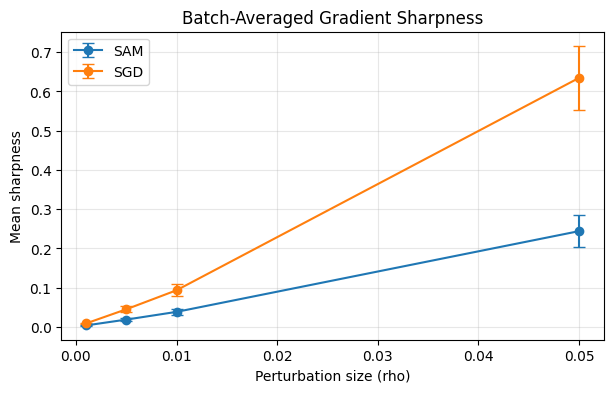

In [46]:
plt.figure(figsize=(7, 4))
for model_name, group in grad_df.groupby("model"):
    plt.errorbar(
        group["rho"],
        group["mean_sharpness"],
        yerr=group["std_sharpness"],
        marker="o",
        capsize=4,
        label=model_name,
    )

plt.xlabel("Perturbation size (rho)")
plt.ylabel("Mean sharpness")
plt.title("Batch-Averaged Gradient Sharpness")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


### How to Read the Main Figure

A lower curve means better local flatness. If the SAM curve stays below the SGD curve as `rho` grows, then SAM is consistently less sensitive to local gradient-aligned perturbations.


## Fixed-Rho Batch Comparison

This gives a second view of flatness by comparing the batch-wise sharpness distribution at a representative perturbation radius. We use `rho = 0.01` because it is large enough to show a clear difference, while still remaining a local perturbation.


In [47]:
focus_rho = 0.01
focus_df = per_batch_df[per_batch_df["rho"] == focus_rho].copy()
focus_df


,batch_index,rho,base_loss,perturbed_loss,sharpness,model
20,0,0.01,0.649953,0.729518,0.079565,SGD
21,1,0.01,0.718546,0.823324,0.104778,SGD
22,2,0.01,0.707474,0.783486,0.076012,SGD
23,3,0.01,0.486721,0.571640,0.084918,SGD
24,4,0.01,0.474680,0.556343,0.081664,SGD
25,5,0.01,1.000882,1.124829,0.123948,SGD
26,6,0.01,1.019165,1.131634,0.112469,SGD
27,7,0.01,0.592787,0.672398,0.079611,SGD
28,8,0.01,0.811892,0.907596,0.095704,SGD
29,9,0.01,0.653545,0.747567,0.094022,SGD


/tmp/ipykernel_8796/2712653340.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(plot_data, labels=["SGD", "SAM"])


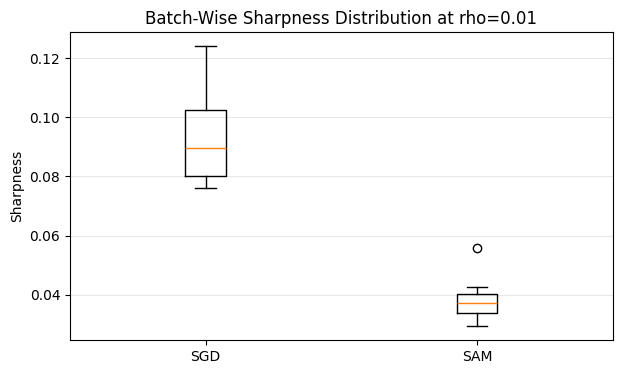

In [48]:
plt.figure(figsize=(7, 4))
plot_data = [
    focus_df[focus_df["model"] == "SGD"]["sharpness"],
    focus_df[focus_df["model"] == "SAM"]["sharpness"],
]

plt.boxplot(plot_data, labels=["SGD", "SAM"])
plt.ylabel("Sharpness")
plt.title(f"Batch-Wise Sharpness Distribution at rho={focus_rho}")
plt.grid(True, axis="y", alpha=0.3)
plt.show()


In [49]:
focus_summary = (
    focus_df.groupby("model")["sharpness"]
    .agg(["mean", "std", "min", "max"])
    .reset_index()
)
focus_summary

,model,mean,std,min,max
0,SAM,0.038204,0.007572,0.029375,0.055864
1,SGD,0.093269,0.016074,0.076012,0.123948


### Interpretation Guide for the Boxplot

This figure checks whether the main conclusion also holds batch-by-batch.

- If the SAM box is lower than the SGD box, then SAM tends to have lower sharpness on most batches, not just on average.
- The table below the boxplot gives a compact numerical summary of the same pattern.


## Suggested Write-Up Notes

You can reuse this logic in the report:

- We evaluated flatness using a gradient-based local sharpness measure on fixed in-distribution test batches.
- For each batch, we perturbed the parameters in the normalized gradient direction and measured the increase in cross-entropy loss.
- Sharpness was consistently lower for SAM than for SGD across all tested perturbation radii.
- At `rho = 0.01`, the batch-wise sharpness distribution of SAM was also clearly shifted downward relative to SGD.
- These results support the traditional explanation that SAM improves generalization by finding flatter minima.


## Save Part B Results

This step writes the key CSVs and figures into the `part_b/` folder so they can be reused in the final report.


In [51]:
part_b_dir = Path(PROJECT_ROOT) / "part_b"
part_b_dir.mkdir(parents=True, exist_ok=True)

grad_df.to_csv(part_b_dir / "batch_averaged_gradient_sharpness.csv", index=False)
per_batch_df.to_csv(part_b_dir / "batch_level_gradient_sharpness.csv", index=False)
focus_summary.to_csv(part_b_dir / "focus_rho_summary.csv", index=False)

plt.figure(figsize=(7, 4))
for model_name, group in grad_df.groupby("model"):
    plt.errorbar(
        group["rho"],
        group["mean_sharpness"],
        yerr=group["std_sharpness"],
        marker="o",
        capsize=4,
        label=model_name,
    )
plt.xlabel("Perturbation size (rho)")
plt.ylabel("Mean sharpness")
plt.title("Batch-Averaged Gradient Sharpness")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(part_b_dir / "batch_averaged_gradient_sharpness.png", dpi=300)
plt.close()

plt.figure(figsize=(7, 4))
plot_data = [
    focus_df[focus_df["model"] == "SGD"]["sharpness"],
    focus_df[focus_df["model"] == "SAM"]["sharpness"],
]
plt.boxplot(plot_data, labels=["SGD", "SAM"])
plt.ylabel("Sharpness")
plt.title(f"Batch-Wise Sharpness Distribution at rho={focus_rho}")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(part_b_dir / "batchwise_sharpness_boxplot.png", dpi=300)
plt.close()

print("Saved files:")
for name in [
    "batch_averaged_gradient_sharpness.csv",
    "batch_level_gradient_sharpness.csv",
    "focus_rho_summary.csv",
    "batch_averaged_gradient_sharpness.png",
    "batchwise_sharpness_boxplot.png",
]:
    print(part_b_dir / name)


/tmp/ipykernel_8796/391484545.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(plot_data, labels=["SGD", "SAM"])


Saved files:
/content/drive/MyDrive/Assignment2_SAM/part_b/batch_averaged_gradient_sharpness.csv
/content/drive/MyDrive/Assignment2_SAM/part_b/batch_level_gradient_sharpness.csv
/content/drive/MyDrive/Assignment2_SAM/part_b/focus_rho_summary.csv
/content/drive/MyDrive/Assignment2_SAM/part_b/batch_averaged_gradient_sharpness.png
/content/drive/MyDrive/Assignment2_SAM/part_b/batchwise_sharpness_boxplot.png
